# Preparation

In [1]:
import numpy as np
from config import create_config
import pandas as pd
import matplotlib.pyplot as plt
import data, models

# Set up problem configuration
config = create_config()  
cache_dir = f"./cache_seed{config.seed}"
print('Seed:', config.seed, 'State Dimension:', config.n_states, 'Horizon:', config.t1_initial, 'Dynamics:',config.system)



Seed: 0 State Dimension: 64 Horizon: 10.0 Dynamics: burgers


# Data Generation

In [2]:
lqr_controller = config.ocp.LQR  # or models.LQRController(config)

dataset, n_attempt, n_fail, sol_time, fail_time = data.generate(
    config.ocp,      # OCP first
    config,          # then config
    n_trajectories=10,
    controller=lqr_controller,
)







# Visualization (uncomment if plot_pde_3d exists)
from plotting import plot_pde_3d
plot_pde_3d(config, ctrl, x0=x0, T_final=10.0)
plt.show()




Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


ModuleNotFoundError: No module named 'plotting'

# Controller Training

In [ ]:
# Controller Training
# Note: train_critic_only implements QRNet-structured CRITIC-ONLY training
# Uses quadratic residual form: V(x) = V_LQR(x) + s(x) * ||x - x_f||^2
# This guarantees V_res(x_f) = 0 and ∇V_res(x_f) = 0 by construction
# Control is computed analytically from ∇V: u(x) = -0.5 R^{-1} B^T ∇V(x)
controllers = {}

controllers["LQR"] = lqr_controller

# Uncomment the controllers you want to train and use.
#controllers["QRNet"] = train_controller("QRNet", config, train_qrnet_supervised, train_args=(config, QRNetTrainConfig(seed=config.seed), XS, GR))
#controllers["QRNet (adaptive)"] = train_controller("QRNet (adaptive)", config, train_qrnet_supervised, train_args=(config, QRNetTrainConfig(seed=config.seed, adaptive=True), XS, GR))

#QRNet-structured critic-only training (quadratic residual architecture)
# The network learns a scalar s(x), and V_res = s(x) * ||x - x_f||^2
# This mathematically enforces LQR behavior at the origin

#controllers["QRNet-Critic-Only"] = train_controller("QRNet-Critic-Only", config, train_critic_only, 
 #   train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed))))

#controllers["QRNet-Critic-Only (adaptive)"] = train_controller("QRNet-Critic-Only (adaptive)", config, train_critic_only, 
    #train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, adaptive_sampling=True))))

#controllers["QRNet-Critic-Only (pretrained)"] = train_controller("QRNet-Critic-Only (pretrained)", config, train_critic_only, 
  #  train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, pretrain=True))))

#controllers["QRNet-Critic-Only (supervised)"] = train_controller("QRNet-Critic-Only (supervised)", config, train_critic_only, 
   # train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, sup_weight=0.1)), sup_data_dict))

controllers["Actor-Critic"] = train_controller("Actor-Critic", config, train_costate_residual, 
    train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed))))

#controllers["Actor-Critic (adaptive)"] = train_controller("Actor-Critic (adaptive)", config, train_costate_residual, 
    #train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, adaptive_sampling=True))))

#controllers["Actor-Critic (pretrained)"] = train_controller("Actor-Critic (pretrained)", config, train_costate_residual, 
 #   train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, pretrain=True))))

#controllers["Actor-Critic (supervised)"] = train_controller("Actor-Critic (supervised)", config, train_costate_residual, 
    #train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, sup_weight=0.1)), sup_data_dict))

#controllers["QRNet-Critic-Only (adaptive)"] = train_controller("QRNet-Critic-Only (adaptive)", config, train_critic_only, 
    #train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, adaptive_sampling=True))))

# Example with custom sampling radius
#controllers["QRNet-Critic-Only (R=3.0)"] = train_controller("QRNet-Critic-Only (R=3.0)", config, train_critic_only,
#    train_args=(config, TrainingSetup(config, ActorCriticTrainConfig(seed=config.seed, R_samp=3.0))))

NameError: name 'train_controller' is not defined

# Evaluation

## Stability

Stability Curve: 100%|██████████| 8/8 [04:49<00:00, 36.21s/it]


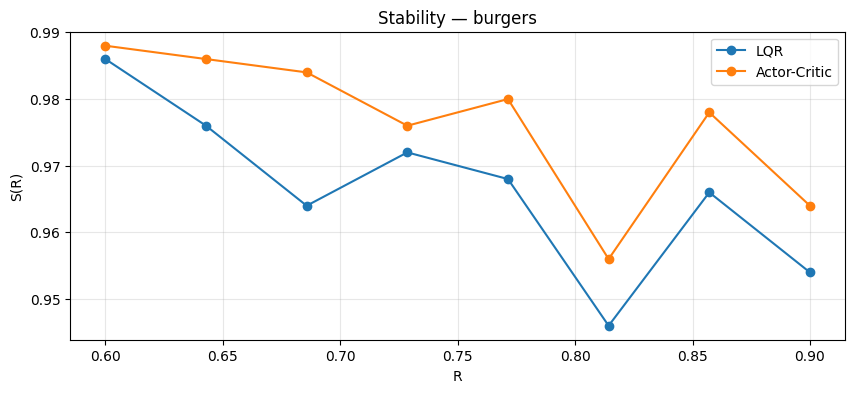

In [ ]:

from matplotlib import pyplot as plt


import evaluation


R_list = np.linspace(0.6, 0.9, 8)

stab = {
    k: evaluation.stability_curve(config, controllers[k], R_list, n_per_R=500, T=10.0, seed=0)
    for k in controllers
}

plt.figure(figsize=(10,4))
for k, df in stab.items():
    plt.plot(df["R"], df["S"], marker="o", label=k)

plt.xlabel("R")
plt.ylabel("S(R)")
plt.title(f"Stability — {config.system}")
plt.legend()
plt.grid(alpha=.3)
plt.show()



In [ ]:
stab_table = evaluation.build_summary_table(config, controllers, Rmax=2.0, T=10.0, n=25, seed=0)[
    ["controller","S_Rmax","tconv_med","tconv_p90"]
]
stab_table


,controller,S_Rmax,tconv_med,tconv_p90
0,LQR,0.76,2.599985,4.915774
1,Actor-Critic,0.72,3.304826,6.587333


## Robustness

In [ ]:
deltas = np.array([0.0, 0.10, 0.20])
rob = {k: evaluation.robustness_curve(config, controllers[k], deltas, n=25, R=1.0, T=10.0, seed=0,
                                     nu_perturb=True, u_noise_std=0.0) for k in controllers}

plt.figure(figsize=(6,4))
for k, df in rob.items(): plt.plot(df["delta"], df["Srob"], marker="o", label=k)
plt.xlabel("delta"); plt.ylabel("S_rob(delta)"); plt.title(f"Robustness — {config.system}"); plt.legend(); plt.grid(alpha=.3); plt.show()


AttributeError: module 'evaluation' has no attribute 'robustness_curve'

In [ ]:
delta_star = 0.10
rob_table = pd.DataFrame([
    {"controller": k,
     f"Srob@{delta_star}": float(df.loc[np.isclose(df["delta"], delta_star), "Srob"].iloc[0]),
     f"Jmean@{delta_star}": float(df.loc[np.isclose(df["delta"], delta_star), "Jmean"].iloc[0])}
    for k, df in rob.items()
]).sort_values(by=f"Srob@{delta_star}", ascending=False)

rob_table


,controller,Srob@0.1,Jmean@0.1
0,LQR,1.00,0.214287
1,QRNet-Critic-Only,0.04,61346.325013
2,QRNet-Critic-Only (adaptive),0.04,46857.303296


## Optimality

/var/folders/jg/2q119j0j72l1swp2qytcflrm0000gn/T/ipykernel_19001/3427887960.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([J[k] for k in controllers], labels=controllers, showfliers=False)


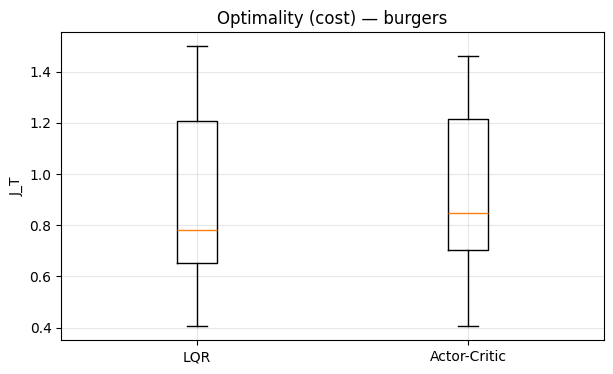

In [ ]:
X0 = evaluation.sample_on_ball(config, n=25, R=1.0, seed=0)
J = {k: np.array([evaluation.rollout_metrics(config, controllers[k], x0, T=10.0)["J"] for x0 in X0]) for k in controllers}

plt.figure(figsize=(7,4))
plt.boxplot([J[k] for k in controllers], labels=controllers, showfliers=False)
plt.ylabel("J_T"); plt.title(f"Optimality (cost) — {config.system}"); plt.grid(alpha=.3); plt.show()


In [ ]:
opt_table = pd.DataFrame([
    {"controller": k,
     "J_mean": float(J[k].mean()),
     "J_median": float(np.median(J[k])),
     "J_p90": float(np.quantile(J[k], 0.9)),
     "gap_vs_LQR_mean": (float(((J[k]-J["LQR"])/(J["LQR"]+1e-9)).mean()) if "LQR" in J else np.nan)}
    for k in controllers
]).sort_values("J_mean")

opt_table


,controller,J_mean,J_median,J_p90,gap_vs_LQR_mean
0,LQR,0.615387,0.622128,0.777388,0.000000
2,QRNet-Critic-Only (adaptive),45176.833465,49977.501181,102331.109292,80475.463225
1,QRNet-Critic-Only,59144.493625,49977.501181,102331.109292,102536.944497


In [ ]:
from evaluation import pmp_validation_metric

results = {}

for name, ctrl in controllers.items():
    results[name] = pmp_validation_metric(
        config,
        ctrl,
        val_pmp,
        T=10.0
    )

import pandas as pd
pd.DataFrame({
    k: {
        "gap_mean": v["gap_mean"],
        "gap_median": v["gap_median"],
        "gap_p90": v["gap_p90"],
        "state_err": v["state_err_mean"],
        "control_err": v["control_err_mean"],
    }
    for k, v in results.items()
}).T.sort_values("gap_mean")


,gap_mean,gap_median,gap_p90,state_err,control_err
LQR,5.857181,5.857181,7.816403,2.036414,0.396207
QRNet-Critic-Only,473205.079266,473205.079266,574223.591127,8.290289,2.289184
QRNet-Critic-Only (adaptive),473205.079266,473205.079266,574223.591127,8.290289,2.289184
